In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
fake = pd.read_csv("C:\\Users\\nisarg\\OneDrive\\Desktop\\data science\\fake_news\\Fake.csv")
true = pd.read_csv("C:\\Users\\nisarg\\OneDrive\\Desktop\\data science\\fake_news\\True.csv")
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [3]:
print(fake.shape)
print(true.shape)

(23481, 4)
(21417, 4)


In [4]:
fake['label']=0
true['label']=1

In [5]:
df=pd.concat([fake,true],ignore_index=True)

In [6]:
df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


In [8]:
df.describe()

,label
count,44898.000000
mean,0.477015
std,0.499477
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [9]:
df.duplicated().sum()
df=df.drop_duplicates()

In [10]:
#check for target imbalance or not
df['label'].value_counts()

label
0    23478
1    21211
Name: count, dtype: int64

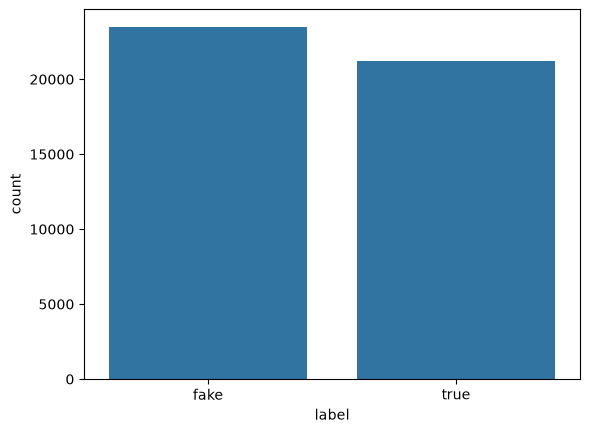

In [11]:
sns.countplot(x="label",data=df)
plt.xticks([0,1],["fake","true"])
plt.show()

In [12]:
#almost balance destribution
(df['label']==True).sum()

np.int64(21211)

In [13]:
df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [14]:
duplicates=df[df["text"].duplicated(keep=False)]
duplicates.groupby("text")["label"].nunique().value_counts()

label
1    4946
2       1
Name: count, dtype: int64

In [15]:
dup=df[df.duplicated(subset=["title", "text"],keep=False)].sort_values(["title","text"])
dup.head(10)

,title,text,subject,date,label
14160,#AnyoneButHillary: NEW POLL Shows Bernie Suppo...,Hillary may find out she needs more than black...,politics,"Apr 6, 2016",0
20771,#AnyoneButHillary: NEW POLL Shows Bernie Suppo...,Hillary may find out she needs more than black...,left-news,"Apr 6, 2016",0
9841,#Austin: Fights Break Out Between Police and S...,Commies carrying flags fought with the Austin ...,politics,"Sep 23, 2017",0
17930,#Austin: Fights Break Out Between Police and S...,Commies carrying flags fought with the Austin ...,left-news,"Sep 23, 2017",0
11756,#Berkeley CRAZY! RIOTERS CHASE And Beat People...,Is anyone else thinking what we re thinking ab...,politics,"Feb 2, 2017",0
19211,#Berkeley CRAZY! RIOTERS CHASE And Beat People...,Is anyone else thinking what we re thinking ab...,left-news,"Feb 2, 2017",0
11755,#Berkeley IRONY ALERT! ANARCHISTS LOOT STARBUC...,Smashing windows How progressive!Protests aga...,politics,"Feb 2, 2017",0
19210,#Berkeley IRONY ALERT! ANARCHISTS LOOT STARBUC...,Smashing windows How progressive!Protests aga...,left-news,"Feb 2, 2017",0
13495,#BlackLivesMatter Supporters Say No Connection...,THE COMMON THREAD IN ALL THIS IS HATE THE HA...,politics,"Jul 17, 2016",0
20259,#BlackLivesMatter Supporters Say No Connection...,THE COMMON THREAD IN ALL THIS IS HATE THE HA...,left-news,"Jul 17, 2016",0


In [16]:
df=df.drop_duplicates(subset=["title","text"])

In [17]:
df.shape

(39105, 5)

In [18]:
#title and text will be our main inputs
df['content']=df['title']+" "+df['text']
df.head(20)

,title,text,subject,date,label,content
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0,Donald Trump Sends Out Embarrassing New Year’...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0,Drunk Bragging Trump Staffer Started Russian ...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0,Sheriff David Clarke Becomes An Internet Joke...
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0,Trump Is So Obsessed He Even Has Obama’s Name...
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0,Pope Francis Just Called Out Donald Trump Dur...
5,Racist Alabama Cops Brutalize Black Boy While...,The number of cases of cops brutalizing and ki...,News,"December 25, 2017",0,Racist Alabama Cops Brutalize Black Boy While...
6,"Fresh Off The Golf Course, Trump Lashes Out A...",Donald Trump spent a good portion of his day a...,News,"December 23, 2017",0,"Fresh Off The Golf Course, Trump Lashes Out A..."
7,Trump Said Some INSANELY Racist Stuff Inside ...,In the wake of yet another court decision that...,News,"December 23, 2017",0,Trump Said Some INSANELY Racist Stuff Inside ...
8,Former CIA Director Slams Trump Over UN Bully...,Many people have raised the alarm regarding th...,News,"December 22, 2017",0,Former CIA Director Slams Trump Over UN Bully...
9,WATCH: Brand-New Pro-Trump Ad Features So Muc...,Just when you might have thought we d get a br...,News,"December 21, 2017",0,WATCH: Brand-New Pro-Trump Ad Features So Muc...


In [19]:
df['label'].value_counts()

label
1    21197
0    17908
Name: count, dtype: int64

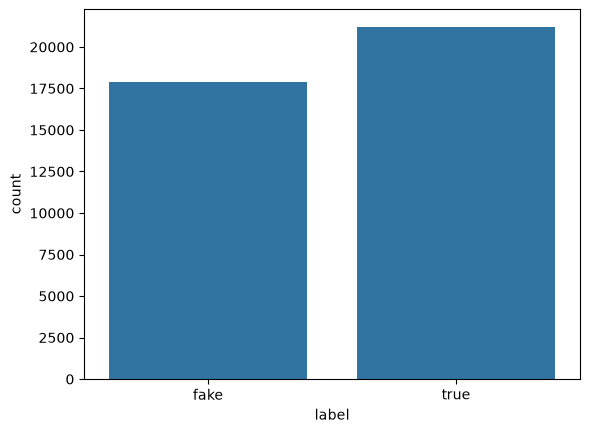

In [20]:
sns.countplot(x="label",data=df)
plt.xticks([0,1],["fake","true"])
plt.show()

In [21]:
df=df[['content','label']]
df.head()
print(df.shape)

(39105, 2)


In [22]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [23]:
df.head()
print(df.shape)

(39105, 2)


In [59]:
x=df['content']
y=df['label']
x

0        Many 'lost' voters say they have found their c...
1        Iranian Revolutionary Guards commander, anothe...
2        Cambodian leader gets China's backing as West ...
3         Ex-KKK Grand Wizard: Maine Gov. Right To Call...
4        FINGER-WAGGING GRANNY HILLARY CLINTON Blows Up...
                               ...                        
39100     Hillary’s Message To Former Miss Universe Cal...
39101    SENIOR CIA INTEL: “Wiretapping of Trump Transi...
39102    Ex-Georgian leader Saakashvili barges across U...
39103     Trump Stole An Idea From North Korean Propaga...
39104    WATCH JUDGE TELL DISRESPECTFUL GANGBANGER Taxp...
Name: content, Length: 39105, dtype: object

In [60]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
x_train.shape

(31284,)

In [61]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [62]:
tfidf = TfidfVectorizer(
    max_features=50000,
    stop_words="english"
)

In [64]:
x_train_tfidf = tfidf.fit_transform(x_train)
x_train_tfidf.shape

(31284, 50000)

In [65]:
x_test_tfidf=tfidf.transform(x_test)

In [67]:
print(x_train_tfidf.shape)
print(x_test_tfidf.shape)

(31284, 50000)
(7821, 50000)


In [68]:
from sklearn.linear_model import LogisticRegression

In [69]:
model = LogisticRegression(max_iter=1000)

In [70]:
model.fit(x_train_tfidf, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [71]:
y_pred = model.predict(x_test_tfidf)

In [72]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9858074415036441


In [73]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      3582
           1       0.98      0.99      0.99      4239

    accuracy                           0.99      7821
   macro avg       0.99      0.99      0.99      7821
weighted avg       0.99      0.99      0.99      7821



In [75]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
cm
# sns.heatmap(
#     cm,
#     annot=True,
#     fmt="d",
#     xticklabels=["Fake", "Real"],
#     yticklabels=["Fake", "Real"]
# )

# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("Confusion Matrix")
# plt.show()

array([[3503,   79],
       [  32, 4207]])

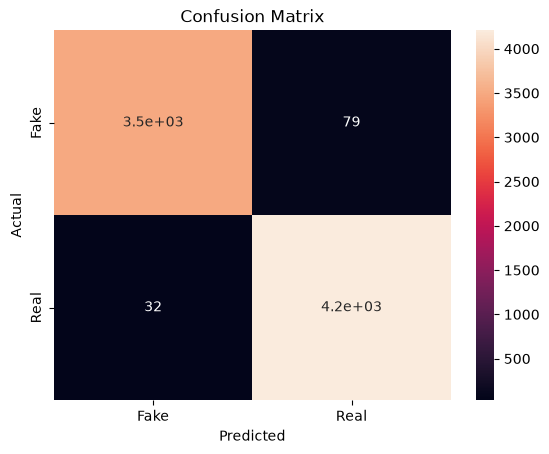

In [82]:
sns.heatmap(
    cm,
    annot=True,
    xticklabels=["Fake","Real"],
    yticklabels=["Fake","Real"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()